In [1]:
import pandas as pd
import numpy as py
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.preprocessing import MinMaxScaler

In [2]:
data=pd.read_csv(r"lung_cancer_examples.csv")
print("Dataset:", data.shape)
data[0:10]

Dataset: (59, 7)


,Name,Surname,Age,Smokes,AreaQ,Alkhol,Result
0,John,Wick,35,3,5,4,1
1,John,Constantine,27,20,2,5,1
2,Camela,Anderson,30,0,5,2,0
3,Alex,Telles,28,0,8,1,0
4,Diego,Maradona,68,4,5,6,1
5,Cristiano,Ronaldo,34,0,10,0,0
6,Mihail,Tal,58,15,10,0,0
7,Kathy,Bates,22,12,5,2,0
8,Nicole,Kidman,45,2,6,0,0
9,Ray,Milland,52,18,4,5,1


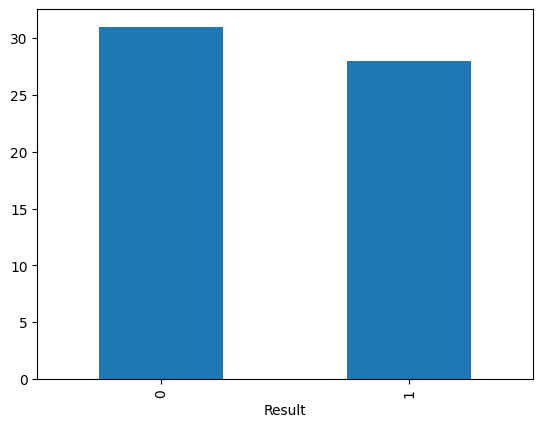

In [3]:
data.Result.value_counts()[0:59].plot(kind="bar")
plt.show()

C:\Users\harik\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\seaborn\axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


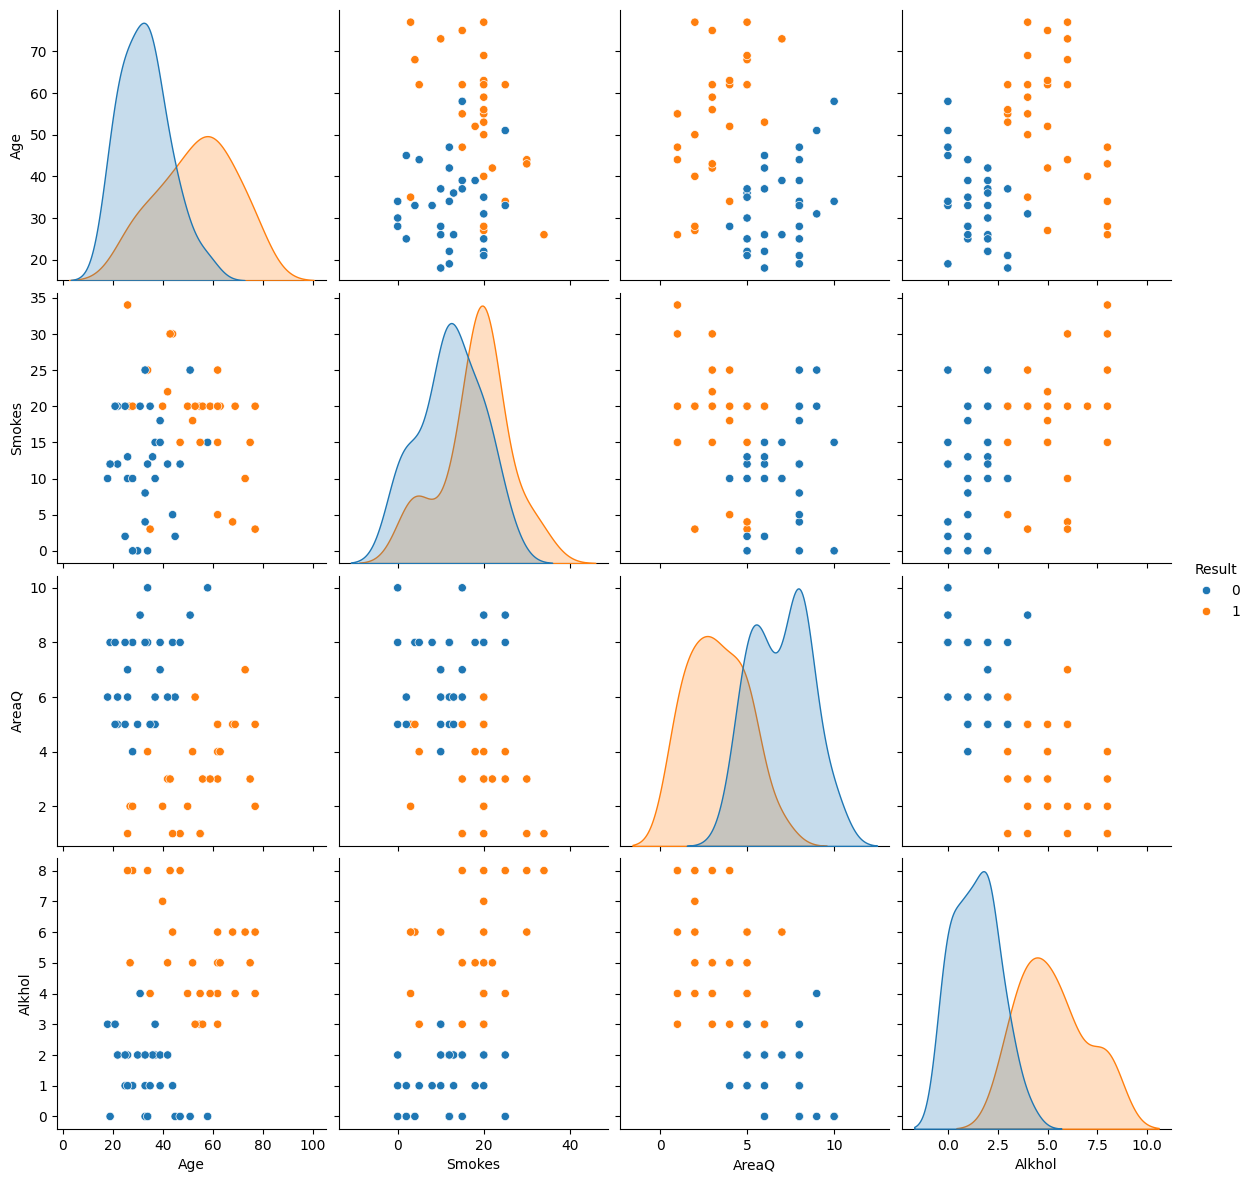

In [4]:
sns.set_style=("whitegrid")
sns.pairplot(data, hue="Result", size=3)
plt.show()

In [5]:
data1=data.drop(columns=['Name','Surname'], axis=1)
print(data1.shape)
data1.head()

(59, 5)


,Age,Smokes,AreaQ,Alkhol,Result
0,35,3,5,4,1
1,27,20,2,5,1
2,30,0,5,2,0
3,28,0,8,1,0
4,68,4,5,6,1


In [6]:
from sklearn.model_selection import train_test_split
Y= data1['Result']
X= data1.drop(columns=['Result'])
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.3, random_state=9)


In [7]:
print("X Train Shape:", X_train.shape)
print("X Test Shape:", X_test.shape)
print("Y Train Shape:", Y_train.shape)
print("X Test Shape:", Y_test.shape)

X Train Shape: (41, 4)
X Test Shape: (18, 4)
Y Train Shape: (41,)
X Test Shape: (18,)


In [8]:
from sklearn.naive_bayes import GaussianNB
nbcla = GaussianNB()
nbcla.fit(X_train, Y_train)
Y_predict1= nbcla.predict(X_test)

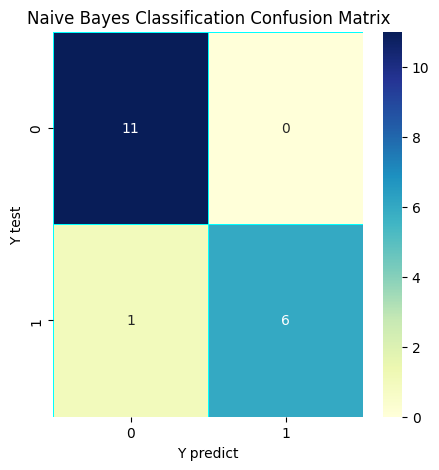

In [9]:
from sklearn.metrics import confusion_matrix
nbcla_cm= confusion_matrix(Y_test,Y_predict1)
f, ax = plt.subplots(figsize=(5,5))
sns.heatmap(nbcla_cm, annot=True, linewidths=0.7, linecolor="cyan", fmt='g', ax=ax, cmap='YlGnBu')
plt.title("Naive Bayes Classification Confusion Matrix")
plt.xlabel("Y predict")
plt.ylabel("Y test")
plt.show()

In [10]:
score_nbcla=nbcla.score(X_test,Y_test)
print(score_nbcla)

0.9444444444444444


In [11]:
from sklearn.tree import DecisionTreeClassifier
dtcla=DecisionTreeClassifier(random_state=9)
dtcla.fit(X_test,Y_test)
Y_predict2=dtcla.predict(X_test)

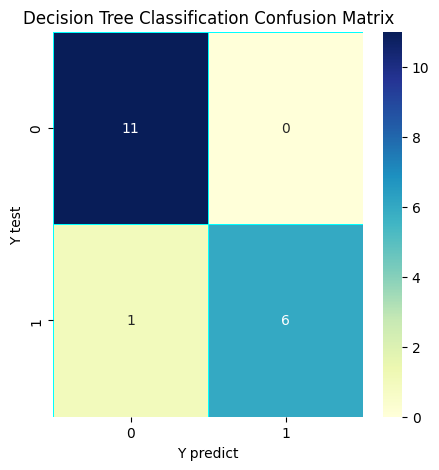

In [12]:
dtcla_cm=confusion_matrix(Y_test, Y_predict2)
f, ax = plt.subplots(figsize=(5,5))
sns.heatmap(nbcla_cm, annot=True, linewidths=0.7, linecolor="cyan", fmt='g', ax=ax, cmap='YlGnBu')
plt.title("Decision Tree Classification Confusion Matrix")
plt.xlabel("Y predict")
plt.ylabel("Y test")
plt.show()

In [13]:
score_dtcla=dtcla.score(X_test,Y_test)
print(score_dtcla)

1.0


In [14]:
Testscores = pd.Series([score_nbcla, score_dtcla], index=['Naive Bayes Score', 'Decision Tree Score'])
print(Testscores)

Naive Bayes Score      0.944444
Decision Tree Score    1.000000
dtype: float64
